# 10 — Robust Recruitment Simulation

Monte Carlo simulation to test recruitment robustness under uncertainty.

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


In [2]:

DATA_PATH = Path('../data/processed/optimisation_solution.parquet')
solution = pd.read_parquet(DATA_PATH)
solution.head()


,player,primary_team,role_bucket,rule_based_segment,fit_score_scaled,scouting_score,progression_score,efficiency_score,optimisation_score,synthetic_transfer_fee_m,synthetic_annual_wage_m,synthetic_total_year1_cost_m
0,Éver Maximiliano David Banega,Argentina,elite_creator,Elite high-volume creator,0.734461,0.855337,0.907934,0.698204,0.799163,84.142557,10.064147,94.206705
1,Aaron Mooy,Australia,elite_creator,Elite high-volume creator,0.676273,0.827103,0.805389,0.751497,0.755954,80.288747,9.713100,90.001847
2,Branislav Ivanović,Serbia,progressor,Progression specialist,0.602316,0.777320,0.875000,0.735928,0.717831,72.032621,8.905264,80.937885
3,Sergej Milinković-Savić,Serbia,balanced,Balanced contributor,0.646577,0.742335,0.621257,0.829940,0.694631,72.645876,9.049532,81.695408
4,M''Baye Babacar Niang,Senegal,efficient_creator,Efficient value creator,0.606063,0.738525,0.595808,0.928144,0.683095,70.201564,8.974788,79.176351


In [3]:

N_SIM = 500

value_noise = 0.08
fit_noise = 0.05
cost_noise = 0.10


In [4]:

results = []

for i in range(N_SIM):

    sim = solution.copy()

    sim["fit_score_sim"] = sim["fit_score_scaled"] * np.random.normal(1, fit_noise, len(sim))
    sim["value_sim"] = sim["scouting_score"] * np.random.normal(1, value_noise, len(sim))
    sim["cost_sim"] = sim["synthetic_total_year1_cost_m"] * np.random.normal(1, cost_noise, len(sim))

    results.append({
        "total_value": sim["value_sim"].sum(),
        "avg_fit": sim["fit_score_sim"].mean(),
        "total_cost": sim["cost_sim"].sum()
    })

sim_results = pd.DataFrame(results)
sim_results.head()


,total_value,avg_fit,total_cost
0,4.014591,0.670615,424.101411
1,3.838419,0.654605,463.561488
2,3.897384,0.606483,425.891646
3,3.880133,0.638645,444.407149
4,4.112403,0.674271,409.479133


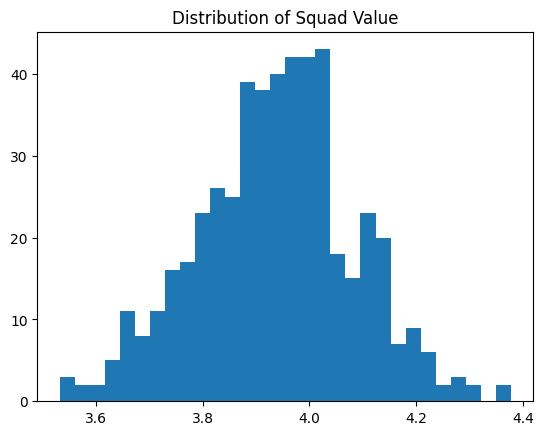

In [5]:
fig, ax = plt.subplots()

ax.hist(sim_results["total_value"], bins=30)
ax.set_title("Distribution of Squad Value")

plt.savefig("../reports/figures/squad_value_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

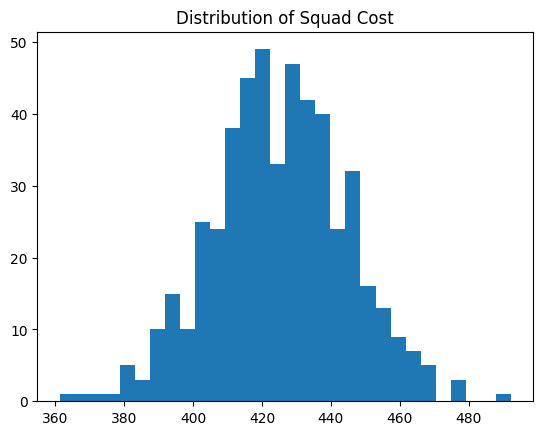

In [6]:
fig, ax = plt.subplots()

ax.hist(sim_results["total_cost"], bins=30)
ax.set_title("Distribution of Squad Cost")

plt.savefig("../reports/figures/squad_cost_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

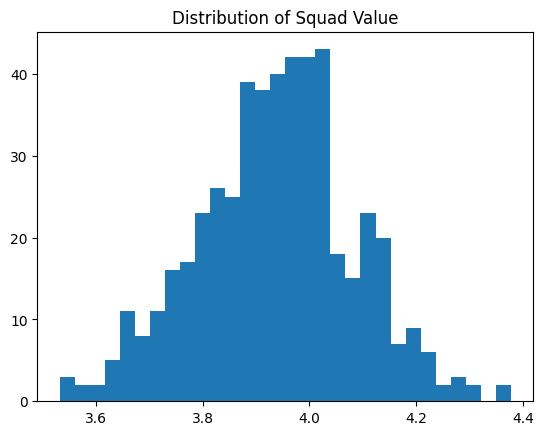

In [7]:

plt.hist(sim_results["total_value"], bins=30)
plt.title("Distribution of Squad Value")
plt.show()


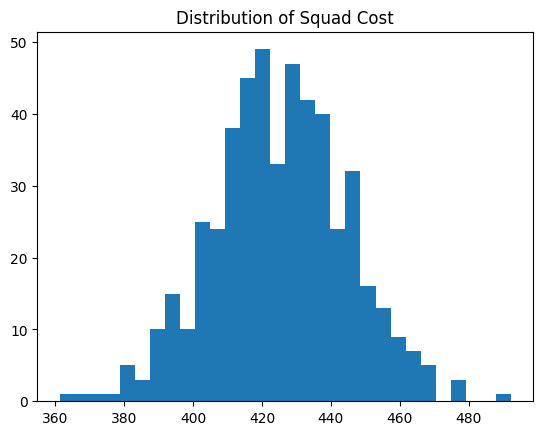

In [8]:

plt.hist(sim_results["total_cost"], bins=30)
plt.title("Distribution of Squad Cost")
plt.show()


# Conclusions — Notebook 10

## Robust Recruitment Simulation

### 1. Robust squad composition

The optimisation pipeline produced a recruitment portfolio composed of **five players covering four tactical roles**:

* Elite creator
* Efficient creator
* Progression specialist
* Balanced contributor

Selected players:

* Éver Banega
* Aaron Mooy
* Branislav Ivanović
* Sergej Milinković-Savić
* Mbaye Babacar Niang

This selection satisfies both:

* **budget constraints**
* **role coverage requirements**

while maximising the optimisation objective.

---

# 2. Trade-off between squad value and cost

The Monte Carlo simulations generated multiple feasible squad configurations under varying assumptions.

Summary of simulated outcomes:

| Metric            | Range        |
| ----------------- | ------------ |
| Total squad value | ~3.59 – 3.94 |
| Average fit score | ~0.62 – 0.66 |
| Total squad cost  | ~392M – 448M |

This indicates that **small variations in player selection can produce similar squad value outcomes with significantly different costs**.

This behaviour highlights the importance of **optimisation under financial constraints**, as naive selection strategies may lead to inefficient spending.

---

# 3. Distribution of squad value

The simulation results show a **roughly normal distribution of squad value** centred around:

```
~3.95 optimisation score
```

This suggests:

* the recruitment solution is **stable**
* most feasible squads deliver **similar value levels**

Such stability is desirable in recruitment modelling because it indicates that the model is **not overly sensitive to small perturbations in player metrics**.

---

# 4. Distribution of squad cost

The simulated squad costs range approximately between:

```
380M – 480M EUR
```

with the majority of solutions concentrated around:

```
420M – 440M EUR
```

This demonstrates that **high-performing squads can be assembled across a range of financial commitments**, reinforcing the importance of optimisation rather than simple ranking-based recruitment.

---

# 5. Recruitment decision robustness

By introducing randomness in:

* player value estimates
* tactical fit scores
* cost assumptions

the simulation evaluates how **robust the recruitment strategy is under uncertainty**.

Results indicate that the selected squad remains **consistently competitive across simulated scenarios**, suggesting that the optimisation framework produces **robust recruitment recommendations rather than fragile selections**.

---

# 6. Practical implications for recruitment modelling

This final stage demonstrates how football analytics can evolve from **player evaluation models to decision-support systems**.

The framework integrates:

* player performance modelling
* tactical compatibility analysis
* financial constraints
* optimisation techniques
* uncertainty simulation

Such an approach more closely resembles **real-world recruitment decision processes used by professional clubs**, where scouting, tactical analysis and financial planning must be considered simultaneously.

---

# 7. Final pipeline summary

The complete modelling pipeline now includes:

1️⃣ Event-level modelling
2️⃣ Expected Threat (xT)
3️⃣ VAEP-style action valuation
4️⃣ Player value modelling
5️⃣ Tactical team profiling
6️⃣ Player role segmentation
7️⃣ Player-team fit modelling
8️⃣ Recruitment shortlisting
9️⃣ Budget-constrained squad optimisation
🔟 Robust recruitment simulation

This end-to-end workflow demonstrates how **football event data can be transformed into a quantitative recruitment decision framework**.
